In [65]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker #For synthetic data generation: Our dataset is missing columns like name, email, and actual 10-digit phone number

In [2]:
df = pd.read_csv('../data/gym_churn_us.csv')

print("\nFirst 5 rows: ")
display(df.head())

print("\nTotal count of rows and columns: ")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\nColumn Names: ")
print(df.columns.tolist())

print("\nInformation of dataset: ")
df.info()


First 5 rows: 


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0



Total count of rows and columns: 
Total Rows: 4000
Total Columns: 14

Column Names: 
['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'Churn']

Information of dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits 

In [ ]:
#What does each column represent!
# gender: The biological sex or gender identity of the gym member.

# Near_Location: Indicates if the member lives or works geographically close to the gym facility.

# Partner: Shows if the member receives a discount through a corporate partnership with their employer.

# Promo_friends: Indicates whether the member originally joined the gym using a friend's referral promo code.

# Phone: Denotes whether the gym has a contact phone number on file for the member.

# Contract_period: The total length of the member's current membership agreement (usually 1, 6, or 12 months).

# Group_visits: Shows whether the member actively participates in group fitness classes.

# Age: The current age of the gym member in years.

# Avg_additional_charges_total: The total extra money the member spends inside the gym on things like protein shakes, towels, or personal training.

# Month_to_end_contract: The exact number of months remaining until the member's current contract expires.

# Lifetime: The total number of months the person has been a member since their very first day.

# Avg_class_frequency_total: The historical average of how many times the member visits the gym per week over their entire lifetime.

# Avg_class_frequency_current_month: The average number of times the member visited the gym per week strictly over the last 30 days.

# Churn: The target variable showing if the member ultimately canceled their membership (1) or stayed (0).

In [3]:
#Data Cleaning step!
print("Missing Values Check")
print(df.isnull().sum())

Missing Values Check
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


In [4]:
#Data Visualization and obtaining insights
sns.set_theme(style="whitegrid") #'whitegrid' theme to enhance the visual clarity of our dashboard.

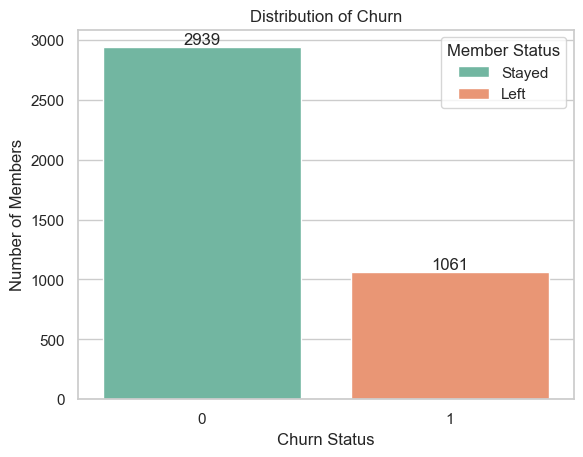

In [9]:
# 1. Check the Class Imbalance (Churners vs. non-churners)
h = sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2')
for container in h.containers:
    h.bar_label(container)
plt.legend(title='Member Status', labels=['Stayed', 'Left'])
plt.title('Distribution of Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Members')
plt.show()

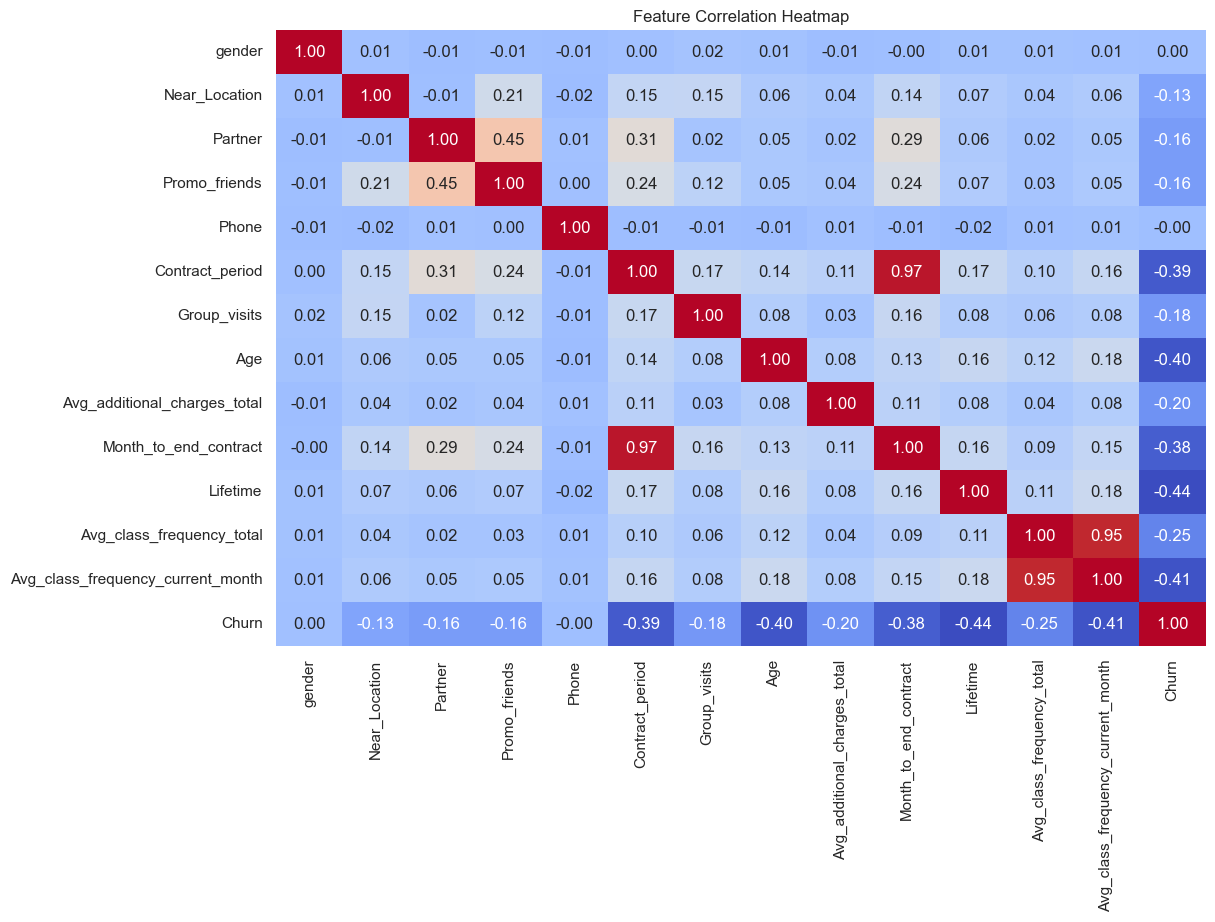

In [11]:
#2. Correlation heatmap: How columns are linked to each other and define churn probability.
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=False)
plt.title('Feature Correlation Heatmap')
plt.show()

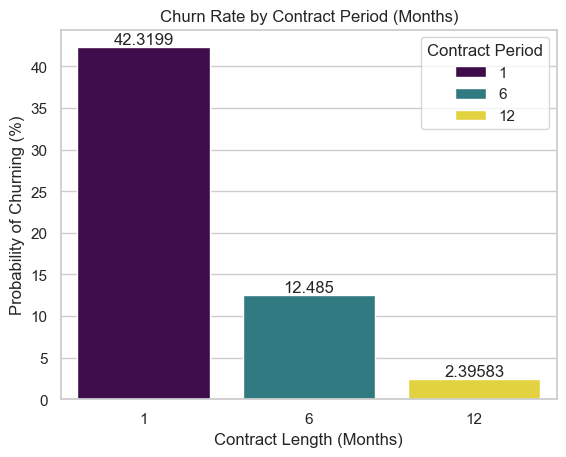



Total Members per Contract Period: 
Contract_period
1     2207
6      833
12     960
Name: count, dtype: int64


In [57]:
# 3. Business Insights: Contract Period vs. Churn
df['Churn_Percentage'] = df['Churn'] * 100
h = sns.barplot(data=df, x='Contract_period', hue='Contract_period', y='Churn_Percentage', palette='viridis', errorbar=None)
for container in h.containers:
    h.bar_label(container)
plt.title('Churn Rate by Contract Period (Months)')
plt.legend(title='Contract Period', labels=['1', '6', '12'])
plt.xlabel('Contract Length (Months)')
plt.ylabel('Probability of Churning (%)')
plt.show()

print("\n\nTotal Members per Contract Period: ")
contract_counts = df['Contract_period'].value_counts().sort_index()
print(contract_counts)

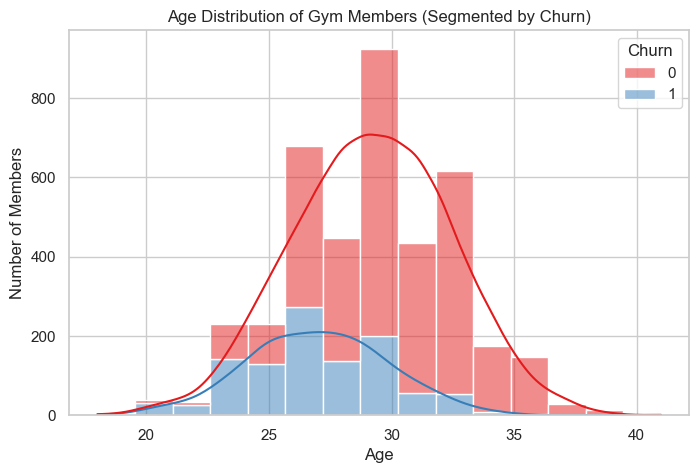


HIGHEST CHURNING BY AGES (By Churn Rate)
 Age  Total_Members  Total_Churned  Churn_Rate_%
  18              2              2        100.00
  21             24             19         79.17
  22             33             26         78.79
  20             14             11         78.57
  23             82             56         68.29
  24            148             87         58.78
  25            231            130         56.28
  19              2              1         50.00
  26            300            133         44.33
  27            378            139         36.77


In [56]:
# 4. Demographic Insight: Age vs. Churn
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Churn', multiple='stack', bins=15, palette='Set1', kde=True)
plt.title('Age Distribution of Gym Members (Segmented by Churn)')
plt.xlabel('Age')
plt.ylabel('Number of Members')
plt.show()

#Group by age
age_stats = df.groupby('Age').agg(
    Total_Members=('Churn', 'count'), 
    Total_Churned=('Churn', 'sum')
).reset_index()

#Calculate the Churn Rate percentage of each age group
age_stats['Churn_Rate_%'] = round((age_stats['Total_Churned'] / age_stats['Total_Members']) * 100, 2)

#Sort by the highest number of churners
age_stats = age_stats.sort_values(by='Churn_Rate_%', ascending=False)

#Display
print("\nHIGHEST CHURNING BY AGES (By Churn Rate)")
print(age_stats.head(10).to_string(index=False))

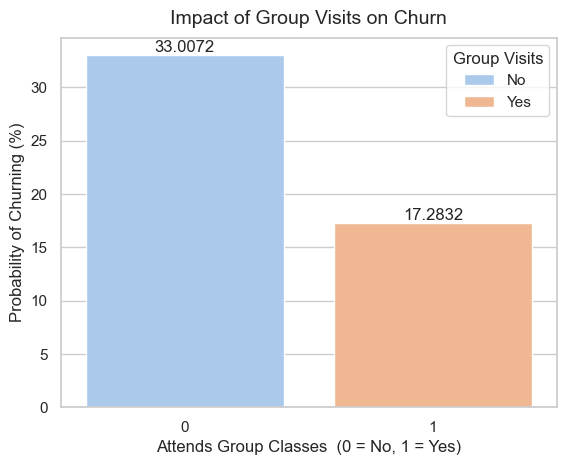

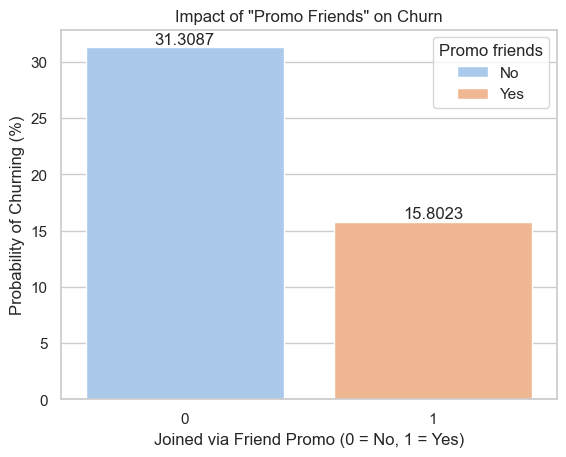

In [38]:
# 5. The Social Factor: Group Visits & Promo Friends

#Group visits vs. churn
df['Churn_Percentage'] = df['Churn'] * 100

h1 = sns.barplot(data=df, x='Group_visits', hue='Group_visits', y='Churn_Percentage', palette='pastel', errorbar=None)

for container in h1.containers:
    h1.bar_label(container)

plt.title('Impact of Group Visits on Churn', fontsize=14, pad=10)
plt.legend(title='Group Visits', labels=['No', 'Yes'])
plt.xlabel('Attends Group Classes  (0 = No, 1 = Yes)')
plt.ylabel('Probability of Churning (%)')
plt.show()

print()

# Promo friend/Referrals vs. Churn
h2 = sns.barplot(data=df, x='Promo_friends', hue='Promo_friends', y='Churn_Percentage', palette='pastel', errorbar=None)

for container in h2.containers:
    h2.bar_label(container)

plt.title('Impact of "Promo Friends" on Churn')
plt.legend(title='Promo friends', labels=['No', 'Yes'])
plt.xlabel('Joined via Friend Promo (0 = No, 1 = Yes)')
plt.ylabel('Probability of Churning (%)')

plt.show()

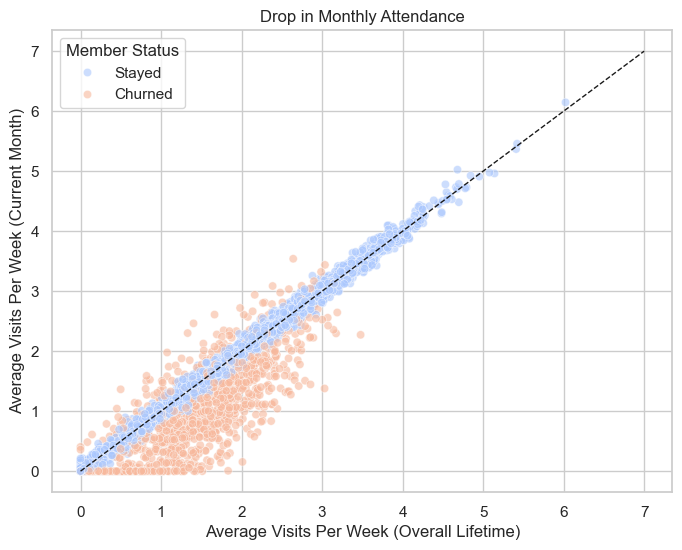

In [41]:
#6. Behavioral/Attendance Drop-off: Comparing their historical attendance vs. this current month's attendance
plt.figure(figsize=(8, 6))
df['Churn_Label'] = df['Churn'].map({0: 'Stayed', 1: 'Churned'})
sns.scatterplot(data=df, x='Avg_class_frequency_total', y='Avg_class_frequency_current_month', hue='Churn_Label', alpha=0.6, palette='coolwarm')
plt.title('Drop in Monthly Attendance')
plt.legend(title ='Member Status')
plt.xlabel('Average Visits Per Week (Overall Lifetime)')
plt.ylabel('Average Visits Per Week (Current Month)')
plt.plot([0, 7], [0, 7], 'k--', linewidth=1) # This line represents historical attendance equals to current attendance
plt.show()

In [42]:
#Feature Engineering

print("Original column count:", len(df.columns))

# 1. The Slacking/Motivation drop off Indicator (All-time average minus this month's average visits)
df['Attendance_Drop'] = df['Avg_class_frequency_total'] - df['Avg_class_frequency_current_month']

# 2. Contract renewal zone (Total contract length minus months remaining)
df['Months_Served'] = df['Contract_period'] - df['Month_to_end_contract']

# 3. Age at Joining (Current age minus lifetime in years)
     #This Column/Feature is to predict Loyal members and not churners!
df['Age_at_Joining'] = round(df['Age'] - (df['Lifetime'] / 12), 1)

print("New column count:", len(df.columns))

display(df[['Attendance_Drop', 'Months_Served', 'Age_at_Joining', 'Churn']].head())

Original column count: 16
New column count: 19


,Attendance_Drop,Months_Served,Age_at_Joining,Churn
0,0.020398,1.0,28.8,0
1,0.012693,0.0,30.4,0
2,0.122596,0.0,27.8,0
3,-0.151582,0.0,32.8,0
4,-0.006194,0.0,25.8,0


In [60]:
#Visualization for the engineered columns with churn!
df['Churn_Label'] = df['Churn'].map({0: 'Stayed', 1: 'Churned'})
churn_colors = {'Stayed': '#a2cffe', 'Churned': '#ffb07c'}

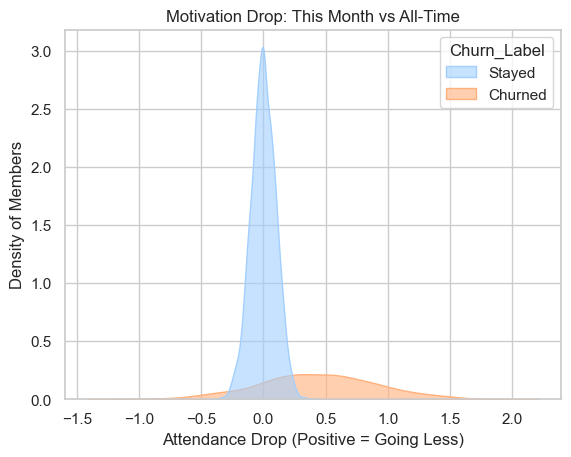

In [49]:
#KDE Plots
sns.kdeplot(data=df, x='Attendance_Drop', hue='Churn_Label', fill=True, palette=churn_colors, alpha=0.6)

plt.title('Motivation Drop: This Month vs All-Time')
plt.xlabel('Attendance Drop (Positive = Going Less)')
plt.ylabel('Density of Members')

plt.show()

In [62]:
#Generate Fake Names, emails, and Phone numbers

fake = Faker('en_IN')

def make_email(name):
    clean_name = name.lower().replace(' ', '.')
    domain = fake.free_email_domain()
    return f"{clean_name}@{domain}"

def make_phone(has_phone):
    if has_phone == 1:
        return fake.phone_number()
    else:
        return 'No Number Provided'

df['Name'] = [fake.name() for _ in range(len(df))]

df['Email'] = df['Name'].apply(make_email)
df['Phone_Number'] = df['Phone'].apply(make_phone)

existing_cols = list(df.columns)
existing_cols.remove('Name')
existing_cols.remove('Email')
existing_cols.remove('Phone_Number')

final_order = ['Name', 'Phone_Number', 'Email'] + existing_cols
df = df[final_order]

display(df.head())

,Name,Phone_Number,Email,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,...,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn,Churn_Percentage,Churn_Label,Attendance_Drop,Months_Served,Age_at_Joining
0,Yashasvi Dash,No Number Provided,yashasvi.dash@gmail.com,1,1,1,1,0,6,1,...,5.0,3,0.020398,0.000000,0,0,Stayed,0.020398,1.0,28.8
1,Aishani Ravi,00963398181,aishani.ravi@gmail.com,0,1,0,0,1,12,1,...,12.0,7,1.922936,1.910244,0,0,Stayed,0.012693,0.0,30.4
2,Yashica Palla,8528332048,yashica.palla@gmail.com,0,1,1,0,1,1,0,...,1.0,2,1.859098,1.736502,0,0,Stayed,0.122596,0.0,27.8
3,Vansha Zacharia,+917966708911,vansha.zacharia@hotmail.com,0,1,1,1,1,12,1,...,12.0,2,3.205633,3.357215,0,0,Stayed,-0.151582,0.0,32.8
4,Isha Bahri,5319049566,isha.bahri@hotmail.com,1,1,1,1,1,1,0,...,1.0,3,1.113884,1.120078,0,0,Stayed,-0.006194,0.0,25.8


In [63]:
#Saving data set
clean_df = df.drop(columns=['Churn_Percentage', 'Churn_Label'], errors='ignore')
clean_df.to_csv('../data/gym_churn_featured.csv', index=False)
print("Dataset saved!")

Dataset saved!
